In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student-marks-data.csv")

In [3]:
df.shape

(50, 5)

In [4]:
df.columns

Index(['study hours', 'attendance percentage', 'previous score', 'sleep hours',
       'marks percentage obtained'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
study hours,0
attendance percentage,0
previous score,0
sleep hours,0
marks percentage obtained,0


In [6]:
df.duplicated().sum()


np.int64(0)

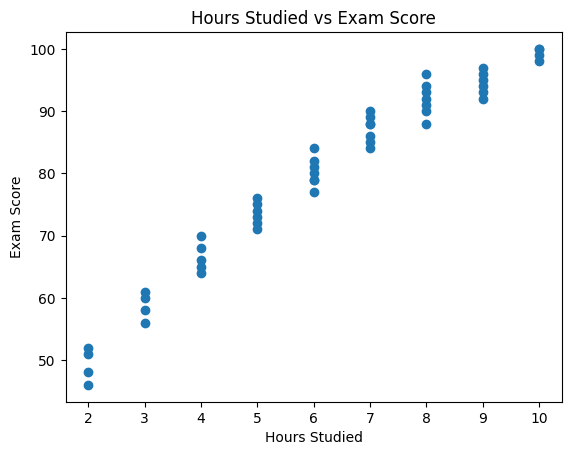

In [9]:
plt.scatter(df['study hours'], df['marks percentage obtained'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

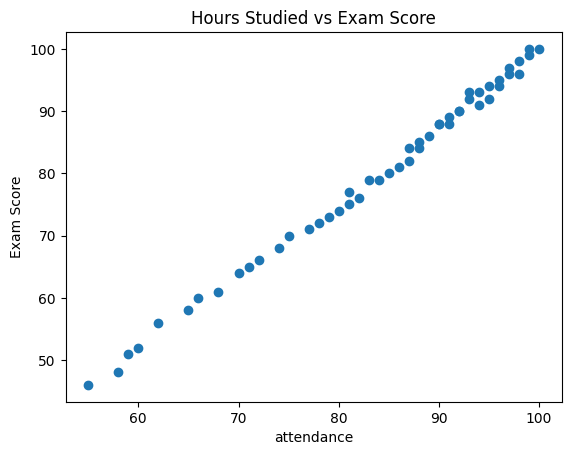

In [11]:
plt.scatter(df['attendance percentage'], df['marks percentage obtained'])
plt.xlabel("attendance")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

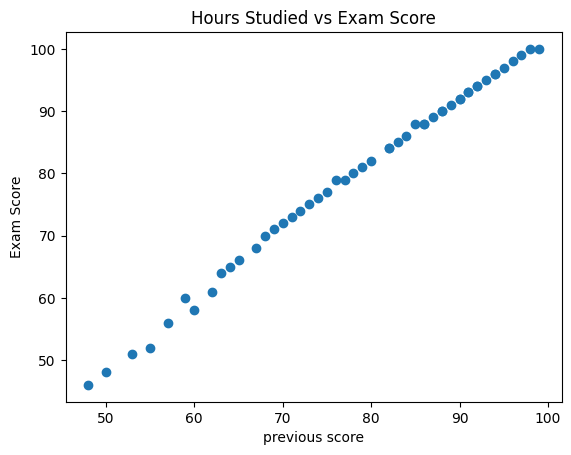

In [12]:
plt.scatter(df['previous score'], df['marks percentage obtained'])
plt.xlabel("previous score")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

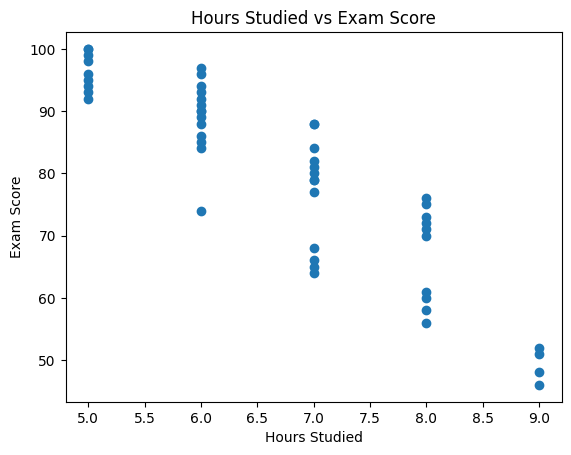

In [13]:
plt.scatter(df['sleep hours'], df['marks percentage obtained'])
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Hours Studied vs Exam Score")
plt.show()

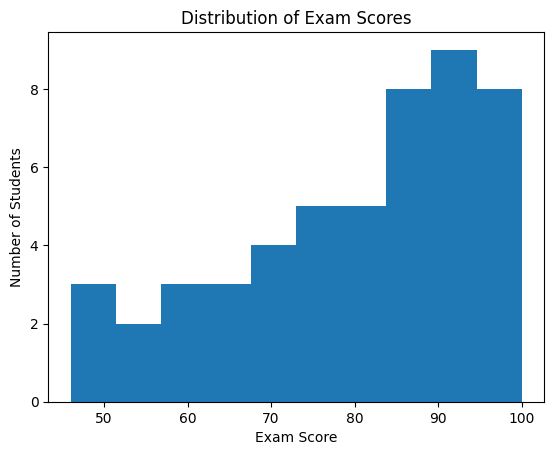

In [14]:
plt.hist(df['marks percentage obtained'])
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")
plt.show()

In [15]:
df.corr(numeric_only=True)

,study hours,attendance percentage,previous score,sleep hours,marks percentage obtained
study hours,1.000000,0.970468,0.982425,-0.905984,0.978367
attendance percentage,0.970468,1.000000,0.993866,-0.885184,0.997706
previous score,0.982425,0.993866,1.000000,-0.902709,0.997960
sleep hours,-0.905984,-0.885184,-0.902709,1.000000,-0.897589
marks percentage obtained,0.978367,0.997706,0.997960,-0.897589,1.000000


In [16]:
from sklearn.model_selection import train_test_split

In [19]:
X = df[['study hours',
        'attendance percentage',
        'previous score',
        'sleep hours']]

In [20]:
y = df['marks percentage obtained']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40, 4)
(10, 4)
(40,)
(10,)


In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
model = LinearRegression()

In [25]:
model.fit(X_train, y_train)

LinearRegression()

In [26]:
print(model.coef_)

[ 0.03430374  0.57460421  0.55540602 -0.03909387]


In [27]:
print(model.intercept_)

-11.836141984946849


In [28]:
y_pred = model.predict(X_test)

In [29]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(comparison.head())

    Actual  Predicted
13      66  65.500310
39      93  92.831866
30      60  58.646851
45      51  51.218788
17      75  75.110206


In [30]:
new_student = [[7, 92, 80, 7]]

prediction = model.predict(new_student)

print("Predicted Marks:", prediction[0])

Predicted Marks: 85.42639616028418


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [32]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.44857359768436


In [33]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.9982205019782364


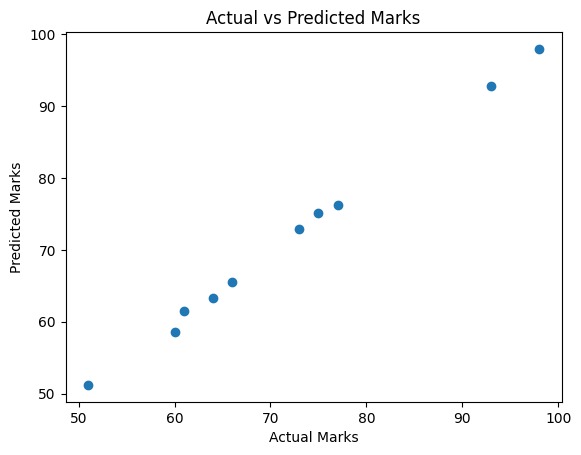

In [34]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

In [36]:
from joblib import dump

dump(model, "student_marks_model.pkl")


['student_marks_model.pkl']